# COMPUTER-INTENSIVE METHODS FOR GENERATING THE SAMPLING DISTRIBUTION

## Objectif pédagogique

Ce notebook illustre les **méthodes informatiques intensives** qui permettent de générer une **distribution d'échantillonnage** à partir d'un seul historique de marché.

L'idée centrale est simple :

> Un backtest donne un résultat observé.  
> Mais pour savoir s'il est solide, il faut le comparer à ce que le hasard aurait pu produire.

Dans le contexte EBTA / Aronson, ces méthodes servent à répondre à une question cruciale :

**Le profit observé vient-il d'un vrai pouvoir prédictif ou simplement d'une chance d'échantillonnage ?**

Nous allons illustrer deux méthodes :

1. **Bootstrap** : rééchantillonnage avec remise des rendements de stratégie.
2. **Permutation Monte Carlo** : mélange aléatoire des signaux pour casser le lien signal → rendement futur.


## 1. Le problème du trader : un seul passé disponible

En trading, nous n'avons généralement qu'un seul historique :

- une seule série de prix ;
- une seule séquence de rendements ;
- une seule période de backtest ;
- un seul résultat final observé.

Le problème est que ce résultat peut être contaminé par la chance.

Une stratégie peut afficher un profit positif non pas parce qu'elle possède un vrai edge, mais parce que la période testée lui a été favorable par hasard.

Les méthodes informatiques intensives permettent de créer artificiellement des milliers de scénarios alternatifs à partir des données disponibles.


## 2. Bootstrap : créer des mondes parallèles par rééchantillonnage

Le **Bootstrap** consiste à tirer au hasard des observations dans l'échantillon original, **avec remise**.

Cela signifie qu'un même jour peut apparaître plusieurs fois dans un échantillon simulé, tandis qu'un autre jour peut ne pas apparaître du tout.

### En trading

Si ton backtest contient 1 000 rendements journaliers de stratégie, le bootstrap crée par exemple 5 000 nouveaux backtests simulés, chacun contenant 1 000 rendements tirés au hasard dans les rendements originaux.

Cela donne une distribution de moyennes possibles.

Cette distribution permet de répondre à une question :

> Si la stratégie n'avait aucun vrai talent, à quel point son rendement moyen pourrait-il varier juste à cause du hasard ?


## 3. Pourquoi zero-center les rendements ?

Pour tester l'hypothèse nulle, on veut simuler un monde où la stratégie **n'a aucun edge**.

Donc on retire la moyenne observée des rendements de stratégie :

$$
r_{zero\ centered} = r_i - \bar{r}
$$

Après cette transformation, la moyenne devient environ zéro.

Cela conserve :

- la volatilité ;
- les extrêmes ;
- la forme de la distribution ;
- les irrégularités des rendements.

Mais cela retire le rendement moyen observé.

On peut ensuite bootstrapper ces rendements zero-centered pour voir ce que le hasard peut produire quand l'edge réel est supposé nul.


## 4. Permutation Monte Carlo : casser le lien prédictif

La permutation Monte Carlo est différente.

Au lieu de rééchantillonner les rendements de stratégie, on garde les rendements du marché et on mélange les signaux.

Exemple :

- rendements du marché : inchangés ;
- signaux de la stratégie : mélangés aléatoirement.

L'objectif est de casser le lien entre le signal et le rendement futur.

Si les signaux mélangés produisent souvent autant de profit que les vrais signaux, alors le résultat réel n'est pas impressionnant.

Mais si le vrai résultat est très rare par rapport aux signaux mélangés, alors il existe potentiellement un vrai pouvoir prédictif.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Paramètres pédagogiques
n_days = 1_000
n_simulations = 5_000

# Créons un faux marché :
# Rendement journalier moyen faible, volatilité réaliste.
market_returns = np.random.normal(loc=0.0002, scale=0.01, size=n_days)

# Créons un signal de trading simplifié :
# +1 = long, -1 = short
signals = np.random.choice([1, -1], size=n_days)

# Ajoutons volontairement un petit edge pédagogique :
# Quand le signal est long, le rendement futur est légèrement meilleur.
# Quand le signal est short, le rendement futur est légèrement moins bon.
edge_strength = 0.0007
future_returns = market_returns + edge_strength * signals

# Rendement de stratégie :
# Si signal = +1, on prend le rendement.
# Si signal = -1, on prend l'inverse du rendement.
strategy_returns = signals * future_returns

observed_mean = strategy_returns.mean()
observed_annualized = observed_mean * 252

print(f"Moyenne journalière observée : {observed_mean:.5%}")
print(f"Rendement annualisé observé : {observed_annualized:.2%}")


Moyenne journalière observée : 0.13389%
Rendement annualisé observé : 33.74%


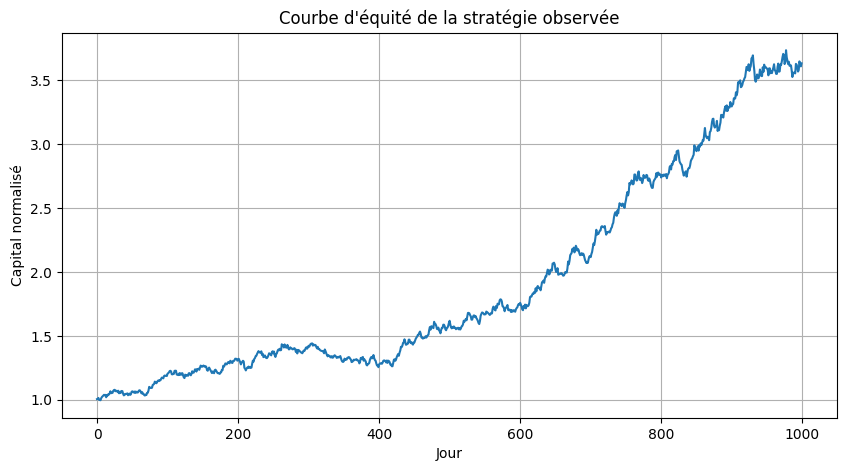

In [2]:
equity_curve = (1 + strategy_returns).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(equity_curve)
plt.title("Courbe d'équité de la stratégie observée")
plt.xlabel("Jour")
plt.ylabel("Capital normalisé")
plt.grid(True)
plt.show()


In [3]:
# Zero-centering : on retire la moyenne observée
zero_centered_returns = strategy_returns - strategy_returns.mean()

print(f"Moyenne avant zero-centering : {strategy_returns.mean():.8f}")
print(f"Moyenne après zero-centering : {zero_centered_returns.mean():.8f}")

bootstrap_means = []

for _ in range(n_simulations):
    sample = np.random.choice(
        zero_centered_returns,
        size=n_days,
        replace=True
    )
    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)

# p-value unilatérale :
# proportion des simulations sans edge qui font au moins aussi bien que le résultat observé.
bootstrap_p_value = np.mean(bootstrap_means >= observed_mean)

print(f"P-value bootstrap : {bootstrap_p_value:.4f}")


Moyenne avant zero-centering : 0.00133886
Moyenne après zero-centering : 0.00000000
P-value bootstrap : 0.0000


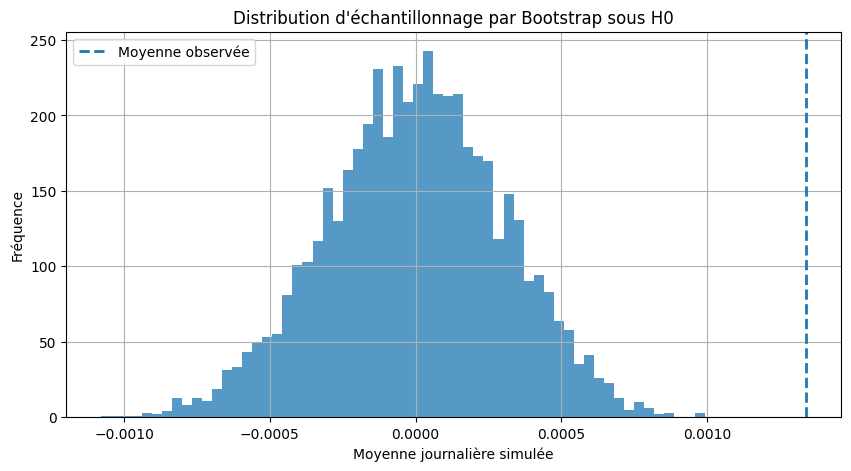

In [4]:
plt.figure(figsize=(10, 5))
plt.hist(bootstrap_means, bins=60, alpha=0.75)
plt.axvline(observed_mean, linestyle="--", linewidth=2, label="Moyenne observée")
plt.title("Distribution d'échantillonnage par Bootstrap sous H0")
plt.xlabel("Moyenne journalière simulée")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
monte_carlo_means = []

for _ in range(n_simulations):
    shuffled_signals = np.random.permutation(signals)
    simulated_strategy_returns = shuffled_signals * future_returns
    monte_carlo_means.append(simulated_strategy_returns.mean())

monte_carlo_means = np.array(monte_carlo_means)

monte_carlo_p_value = np.mean(monte_carlo_means >= observed_mean)

print(f"P-value Monte Carlo par permutation : {monte_carlo_p_value:.4f}")


P-value Monte Carlo par permutation : 0.0000


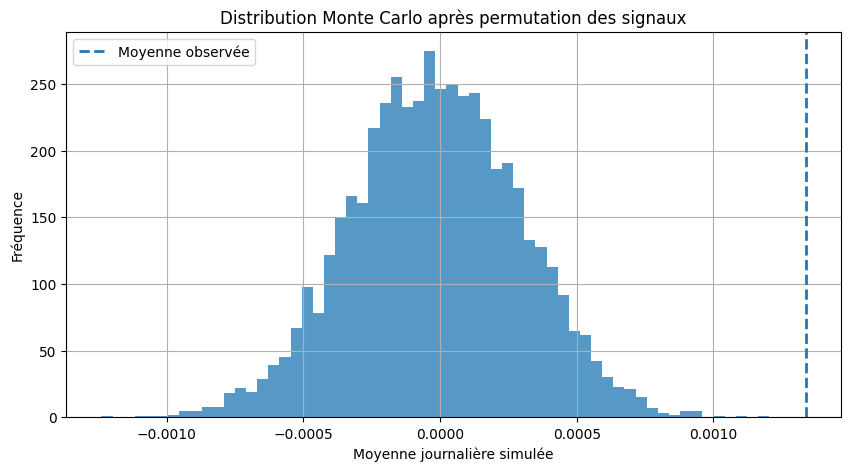

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(monte_carlo_means, bins=60, alpha=0.75)
plt.axvline(observed_mean, linestyle="--", linewidth=2, label="Moyenne observée")
plt.title("Distribution Monte Carlo après permutation des signaux")
plt.xlabel("Moyenne journalière simulée")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(True)
plt.show()


In [7]:
summary = pd.DataFrame({
    "Méthode": ["Bootstrap zero-centered", "Permutation Monte Carlo"],
    "Question testée": [
        "Que peut produire le hasard si les rendements de stratégie ont une moyenne nulle ?",
        "Que peut produire le hasard si les signaux n'ont aucun lien avec les rendements futurs ?"
    ],
    "P-value": [bootstrap_p_value, monte_carlo_p_value]
})

summary


,Méthode,Question testée,P-value
0,Bootstrap zero-centered,Que peut produire le hasard si les rendements ...,0.0
1,Permutation Monte Carlo,Que peut produire le hasard si les signaux n'o...,0.0


## 5. Interprétation façon trader

La **p-value** mesure la proportion de simulations de hasard qui font aussi bien ou mieux que le résultat observé.

Exemple :

- p-value = 0,40 → le résultat observé est banal ; le hasard fait souvent aussi bien.
- p-value = 0,08 → résultat intéressant, mais pas toujours suffisant selon le seuil choisi.
- p-value = 0,03 → résultat rare sous l'hypothèse nulle ; on peut envisager de rejeter H0.

### Lecture EBTA

Le but n'est pas de dire :

> Ma stratégie a gagné, donc elle est bonne.

Le but est de dire :

> Si ma stratégie n'avait aucun talent, ce résultat serait-il rare ?

C'est cette logique qui transforme un simple backtest en preuve statistique.


## 6. Exemple concret trading

Imagine que tu testes une règle ICT / price action sur 1 000 jours.

Ton backtest donne :

- rendement moyen journalier positif ;
- courbe d'équité montante ;
- profit factor correct.

Mais cela ne suffit pas.

Tu dois maintenant créer une distribution de hasard :

### Avec Bootstrap

Tu prends les rendements de la stratégie, tu retires leur moyenne, puis tu les rééchantillonnes des milliers de fois.

Cela te dit ce qu'une stratégie sans edge pourrait produire par simple variation d'échantillonnage.

### Avec Monte Carlo

Tu mélanges les signaux pour casser le lien entre ton setup et le rendement futur.

Cela te dit si tes signaux font mieux que des signaux aléatoires.

Si ton vrai résultat est très supérieur aux deux distributions simulées, ton signal devient beaucoup plus crédible.


## 7. À retenir absolument

- Un backtest unique ne suffit pas.
- Le profit observé doit être comparé à une distribution de résultats générés par le hasard.
- Le Bootstrap recycle les rendements avec remise.
- Le zero-centering force l'hypothèse nulle : moyenne égale à zéro.
- La permutation Monte Carlo mélange les signaux pour casser le lien prédictif.
- Ces méthodes permettent de calculer une p-value.
- Plus la p-value est faible, plus le résultat observé est rare sous H0.
- En trading, ce processus protège contre le piège : confondre chance et talent.


## Contenu source fourni

### **COMPUTER-INTENSIVE METHODS FOR GENERATING THE SAMPLING DISTRIBUTION**

Voici l’analyse des méthodes informatiques intensives utilisées pour générer la distribution d’échantillonnage, une étape cruciale pour valider scientifiquement les signaux de trading selon David Aronson.

#### **Idées clés :**
*   **Alternative à l'approche classique :** Ces méthodes remplacent les formules mathématiques de Sir Ronald Fisher par des simulations de puissance de calcul,.
*   **Solution au "problème de l'échantillon unique" :** Elles permettent d'estimer la variabilité d'une règle alors que le trader ne dispose que d'un seul historique de marché,.
*   **Recyclage des données :** Elles créent des milliers de nouveaux échantillons en réutilisant systématiquement les données originales,.
*   **Deux piliers :** Le **Bootstrap** (rééchantillonnage avec remise) et la **Permutation de Monte Carlo** (appariement aléatoire),.

---

#### **Référence :**
*COMPUTER-INTENSIVE METHODS FOR GENERATING THE SAMPLING DISTRIBUTION* (Pages 215, 234–243 ; Audiobook 209-210).

---

#### **Citation Directe :**
« Computer-intensive methods estimate the sampling distribution's shape by randomly resampling (reusing) the original sample of observation so as to produce new computer-generated samples. » (Page 234).

---

#### **Vision Macro :**
L'enjeu est de briser la barrière du "passé unique". Aronson explique que dans le monde réel, nous n'avons qu'un seul échantillon historique de données de marché,. Or, un seul chiffre de profit ne dit rien sur sa propre variabilité. Les méthodes informatiques intensives simulent ce qui se passerait si nous pouvions tester notre stratégie dans des milliers d'univers parallèles où les composants aléatoires du marché seraient différents,. Cela permet de définir un **étalon du hasard** (benchmark) pour savoir si un profit est dû au talent ou à la simple variabilité d'échantillonnage,.

---

#### **Vision Micro :**

1.  **Le mécanisme de base :** L'ordinateur prend l'échantillon original (ex: 1 231 jours de backtest) et le traite comme s'il s'agissait de la population entière. Il génère ensuite environ 5 000 nouveaux échantillons par tirage aléatoire,.
2.  **La méthode Bootstrap (Lifting itself up) :**
    *   **Processus :** On effectue un rééchantillonnage **avec remise**,. Un jour spécifique peut être sélectionné plusieurs fois ou jamais dans une simulation donnée.
    *   **Finalité :** Elle sert à approximer la forme de la distribution des rendements moyens pour des règles sans talent,.
3.  **La méthode de Permutation Monte Carlo (MCP) :**
    *   **Processus :** Elle "brouille" les cartes. On prend les signaux de la règle (+1 / -1) et on les associe de manière aléatoire aux rendements quotidiens du marché,.
    *   **Finalité :** Elle brise tout lien prédictif entre le signal et le prix pour créer une "règle de bruit". La distribution de ces règles de bruit sert de point de comparaison au backtest réel,.

---

#### **Résumé Simplifié :**
Puisqu'on ne peut pas voyager dans le temps pour tester notre stratégie sur de nouvelles données, on utilise l'ordinateur pour "mélanger" le passé de milliers de façons différentes,. Cela crée une montagne de résultats de "chance pure". Si ton vrai résultat est tout en haut de cette montagne, là où le hasard n'arrive presque jamais, alors ta stratégie a un vrai pouvoir prédictif,.

---

#### **Exemples du livre pour mieux comprendre :**
*   **La règle TT-4-91 :** Aronson teste une cassure de canal sur 91 jours. Le Bootstrap génère 5 000 moyennes simulées après avoir centré les données sur zéro. La p-value obtenue est de 0,069, ce qui signifie que 6,9 % des tests de pur hasard ont fait aussi bien que la règle réelle.
*   **L'analogie de la roulette :** La méthode Monte Carlo est comparée à l'utilisation de l'ordinateur comme une roue de casino pour s'assurer que les positions d'achat/vente ne sont pas simplement corrélées au hasard avec les mouvements du marché,.

---

#### **Actions Concrètes :**
*   **Simuler massivement :** Ne vous contentez pas d'un seul backtest ; lancez au moins 5 000 itérations informatiques pour obtenir une distribution stable,.
*   **Choisir sa méthode :** Utilisez le Bootstrap si vous voulez tester la profitabilité moyenne et Monte Carlo si vous voulez prouver que vos signaux ne sont pas juste du bruit corrélé,.
*   **Vérifier la taille N :** Assurez-vous que chaque échantillon simulé a exactement la même taille que votre échantillon original (Bootstrap Theorem),.

---

#### **À retenir absolument :**
*   Ces méthodes **quantifient l'incertitude** causée par le hasard de l'échantillonnage,.
*   Elles ne nécessitent pas que les données suivent une courbe en cloche parfaite (Central Limit Theorem),.
*   Elles fournissent la base mathématique pour calculer la **p-value**,.
*   Le **Bootstrap** utilise le rééchantillonnage avec remise ; **Monte Carlo** utilise la permutation sans remise,.
*   C'est la seule façon rigoureuse de transformer un backtest unique en une preuve statistique.

J'ai terminé l'analyse des méthodes informatiques intensives pour générer la distribution d'échantillonnage selon le protocole EBTA.
